In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:33374")
client

<Client: 'tcp://127.0.0.1:33374' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns
import xrft

import glob

import gcm_filters

import os.path as op

from scipy.interpolate import griddata, interpn

import warnings
warnings.filterwarnings("ignore")

# from xeofs.models import EOF
from pydmd import DMD, BOPDMD, MrDMD
from pydmd.mrcosts import mrCOSTS
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

In [4]:
for mm in range(4,8):
    if mm == 4:
        for dd in range(1,31):
            if dd == 1:
                dsc = xr.open_dataset(op.join(ddir,
                            "../CMEMS/2023-%02d/dt_global_allsat_phy_l4_2023%02d%02d_20241023.nc"
                                             % (mm, mm, dd)),
                                     engine="netcdf4"
                                     ).chunk({"latitude":720,
                                              "longitude":720})
            else:
                dsc = xr.concat([dsc, 
                                xr.open_dataset(op.join(ddir,
                            "../CMEMS/2023-%02d/dt_global_allsat_phy_l4_2023%02d%02d_20241023.nc"
                                             % (mm, mm, dd)),
                                     engine="netcdf4"
                                               ).chunk({"latitude":720,
                                                        "longitude":720})
                               ], "time")
    elif mm == 5:
        for dd in range(1,32):
            dsc = xr.concat([dsc, 
                             xr.open_dataset(op.join(ddir,
                            "../CMEMS/2023-%02d/dt_global_allsat_phy_l4_2023%02d%02d_20241023.nc"
                                             % (mm, mm, dd)),
                                     engine="netcdf4"
                                            ).chunk({"latitude":720,
                                                     "longitude":720})
                               ], "time")
    elif mm == 6:
        for dd in range(1,31):
            dsc = xr.concat([dsc, 
                             xr.open_dataset(op.join(ddir,
                            "../CMEMS/2023-%02d/dt_global_allsat_phy_l4_2023%02d%02d_20241023.nc"
                                             % (mm, mm, dd)),
                                     engine="netcdf4"
                                            ).chunk({"latitude":720,
                                                     "longitude":720})
                               ], "time")
    else:
        for dd in range(1,11):
            dsc = xr.concat([dsc, 
                             xr.open_dataset(op.join(ddir,
                            "../CMEMS/2023-%02d/dt_global_allsat_phy_l4_2023%02d%02d_20241023.nc"
                                             % (mm, mm, dd)),
                                     engine="netcdf4"
                                            ).chunk({"latitude":720,
                                                     "longitude":720})
                               ], "time")
dsc

<xarray.Dataset> Size: 34GB
Dimensions:         (time: 101, latitude: 1440, nv: 2, longitude: 2880)
Coordinates:
  * time            (time) datetime64[ns] 808B 2023-04-01 ... 2023-07-10
  * latitude        (latitude) float32 6kB -89.94 -89.81 -89.69 ... 89.81 89.94
  * nv              (nv) int32 8B 0 1
  * longitude       (longitude) float32 12kB -179.9 -179.8 ... 179.8 179.9
Data variables: (12/14)
    crs             (time) int32 404B -2147483647 -2147483647 ... -2147483647
    lat_bnds        (time, latitude, nv) float32 1MB dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    lon_bnds        (time, longitude, nv) float32 2MB dask.array<chunksize=(1, 720, 2), meta=np.ndarray>
    sla             (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    err_sla         (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    ugosa           (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    ...              ...
    err_vgosa       (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    adt             (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    ugos            (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    vgos            (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    flag_ice        (time, latitude, longitude) float64 3GB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
    tpa_correction  (time) float64 808B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/42)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    geospatial_vertical_units:       m
    time_coverage_duration:          P1D
    time_coverage_resolution:        P1D
    time_coverage_end:               2023-04-01T12:00:00Z
    time_coverage_start:             2023-03-31T12:00:00Z
    platform:                        Cryosat-2 New Orbit, Sentinel-3B, Altika...

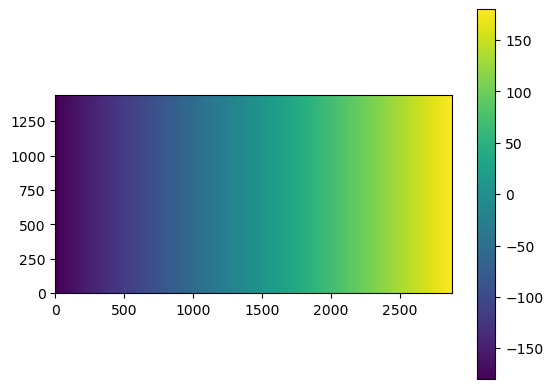

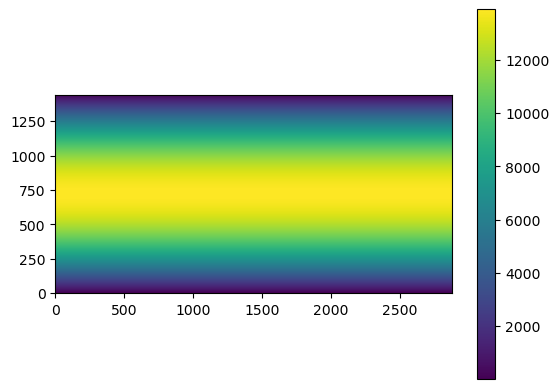

(<xarray.DataArray (time: 101, latitude: 1438, longitude: 2878)> Size: 3GB
 dask.array<xarray-<this-array>, shape=(101, 1438, 2878), dtype=float64, chunksize=(1, 1438, 2878), chunktype=numpy.ndarray>
 Coordinates:
   * latitude   (latitude) float32 6kB -89.81 -89.69 -89.56 ... 89.56 89.69 89.81
   * longitude  (longitude) float32 12kB -179.8 -179.7 -179.6 ... 179.7 179.8
 Dimensions without coordinates: time,
 <xarray.DataArray (time: 101, latitude: 1438, longitude: 2878)> Size: 3GB
 dask.array<xarray-<this-array>, shape=(101, 1438, 2878), dtype=float64, chunksize=(1, 1438, 2878), chunktype=numpy.ndarray>
 Coordinates:
   * latitude   (latitude) float32 6kB -89.81 -89.69 -89.56 ... 89.56 89.69 89.81
   * longitude  (longitude) float32 12kB -179.8 -179.7 -179.6 ... 179.7 179.8
 Dimensions without coordinates: time)

In [15]:
# fiso = gsw.f(daviso.latitude.isel(latitude=slice(1,-1)))
# lonviso, latviso = np.meshgrid(daviso.longitude, daviso.latitude)

# dxiso = gsw.distance(lonviso, latviso, p=0, axis=-1)
# dyiso = gsw.distance(lonviso, latviso, p=0, axis=0)

# u_xiso = ( np.diff(daviso.ugos,axis=-1) / dxiso )
# v_yiso = ( np.diff(daviso.vgos,axis=-2) / dyiso )
# u_xiso = .5*(u_xiso[...,1:-1,1:] + u_xiso[...,1:-1,:-1])
# v_yiso = .5*(v_yiso[...,:-1,1:-1] + v_yiso[...,1:,1:-1])

# u_yiso = ( np.diff(daviso.ugos,axis=-2) / dyiso )
# v_xiso = ( np.diff(daviso.vgos,axis=-1) / dxiso )
# u_yiso = .5*(u_yiso[...,:-1,1:-1] + u_yiso[...,1:,1:-1])
# v_xiso = .5*(v_xiso[...,1:-1,1:] + v_xiso[...,1:-1,:-1])
        
# vortiso = v_xiso - u_yiso

# sniso = u_xiso - v_yiso
# ssiso = v_xiso + u_yiso
# strainiso = np.sqrt(sniso**2 + ssiso**2)

lon, lat = np.meshgrid(dsc.longitude, dsc.latitude)
dx = gsw.distance(lon, lat,)
dy = gsw.distance(lon, lat, axis=0)
plt.imshow(lon, origin="lower")
plt.colorbar()
plt.show()
plt.imshow(dx, origin="lower")
plt.colorbar()
plt.show()
# plt.imshow(la, origin="lower")
# plt.colorbar()
# plt.show()
# plt.imshow(dy, origin="lower")
# plt.colorbar()
# plt.show()

cori = gsw.f(dsc.latitude.isel(latitude=slice(1,-1)))

# vx = dsc.vgosa.diff("longitude") / dx
# uy = dsc.ugosa.diff("latitude") / dy
vx = ( np.diff(dsc.vgosa,axis=-1) / dx )
uy = ( np.diff(dsc.ugosa,axis=-2) / dy )
# vx = vx.rolling(longitude=2,min_periods=1
#                ).mean().isel(longitude=slice(1,None),
#                              latitude=slice(1,-1))
# uy = uy.rolling(latitude=2,min_periods=1
#                ).mean().isel(latitude=slice(1,None),
#                              longitude=slice(1,-1))
u_y = .5*(uy[...,:-1,1:-1] + uy[...,1:,1:-1])
v_x = .5*(vx[...,1:-1,1:] + vx[...,1:-1,:-1])
vort = xr.DataArray((v_x - u_y.data) / np.abs(cori.data)[np.newaxis,:,np.newaxis],
                    dims=["time","latitude","longitude"],
                    coords={"latitude":dsc.latitude.isel(latitude=slice(1,-1)).data,
                            "longitude":dsc.longitude.isel(longitude=slice(1,-1)).data
                           }
                   ).chunk({"time":1})

# ux = dsc.ugosa.diff("longitude") / dx
# vy = dsc.vgosa.diff("latitude") / dy
ux = ( np.diff(dsc.ugosa,axis=-1) / dx )
vy = ( np.diff(dsc.vgosa,axis=-2) / dy )
# ux = ux.rolling(longitude=2,min_periods=1
#                ).mean().isel(longitude=slice(1,None),
#                              latitude=slice(1,-1))
# vy = vy.rolling(latitude=2,min_periods=1
#                ).mean().isel(latitude=slice(1,None),
#                              longitude=slice(1,-1))
u_x = .5*(ux[...,1:-1,1:] + ux[...,1:-1,:-1])
v_y = .5*(vy[...,:-1,1:-1] + vy[...,1:,1:-1])
strain = xr.DataArray((np.sqrt((u_x-v_y.data)**2
                              + (v_x+u_y.data)**2)
                     ) / np.abs(cori.data)[np.newaxis,:,np.newaxis],
                    dims=["time","latitude","longitude"],
                    coords={"latitude":dsc.latitude.isel(latitude=slice(1,-1)).data,
                            "longitude":dsc.longitude.isel(longitude=slice(1,-1)).data
                           }
                   ).chunk({"time":1})


vort, strain

# Agulhas Current

In [59]:
ds01 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 1))
ds01.coords["num_lines"] = ("num_lines",range(len(ds01.num_lines)))
ds01.coords["num_pixels"] = ("num_pixels",range(len(ds01.num_pixels)))

ds16 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 16))
ds16.coords["num_lines"] = ("num_lines",range(len(ds16.num_lines)))
ds16.coords["num_pixels"] = ("num_pixels",range(len(ds16.num_pixels)))
ds01,ds16

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [60]:
maskn1 = xr.DataArray(ds01.latitude.where(ds01.latitude>-38.2).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
masks1 = xr.DataArray(ds01.latitude.where(ds01.latitude<-33).to_masked_array().mask,
                     dims=ds01.latitude.dims,
                     coords=ds01.latitude.coords
                    )
xo01 = ds01.where(~maskn1,drop=True).where(~masks1,drop=True)

maskn6 = xr.DataArray(ds16.latitude.where(ds16.latitude>-38.2).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
masks6 = xr.DataArray(ds16.latitude.where(ds16.latitude<-33).to_masked_array().mask,
                     dims=ds16.latitude.dims,
                     coords=ds16.latitude.coords
                    )
xo16 = ds16.where(~maskn6,drop=True).where(~masks6,drop=True)
xo01, xo16

(<xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 171kB -38.19 -38.2 ... -33.0
     longitude     (num_lines, num_pixels) float64 171kB 14.54 14.56 ... 17.44
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 18MB dask.array<chunksize=(1, 310, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 18MB
 Dimensions:       (cycle_num: 105, num_lines: 310, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 2kB 6775 6776 6777 6778 ... 7082 7083 7084
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 

In [61]:
inp = 3

mask01 = xr.DataArray(xo01.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo01.ssha_detided.isel(cycle_num=0).coords
                    )
mm01 = xr.DataArray(mask01.where(mask01<.5
                              ).to_masked_array().mask,
                   dims=xo01.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo01.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask16 = xr.DataArray(xo16.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo16.ssha_detided.isel(cycle_num=0).coords
                    )
mm16 = xr.DataArray(mask16.where(mask16<.5
                              ).to_masked_array().mask,
                   dims=xo16.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo16.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm01, mm16

(<xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(310, 63))
 Coordinates:
   * num_lines   (num_lines) int64 2kB 2777 2778 2779 2780 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 156kB -38.2 -38.21 ... -32.99
     longitude   (num_lines, num_pixels) float64 156kB 14.61 14.63 ... 17.38,
 <xarray.DataArray (num_lines: 310, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  Tr

In [62]:
low01 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 1)
                      ).ssha.where(~maskn1,drop=True).where(~masks1,drop=True)
low16 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass%03d/SSHa.zarr" 
                               % 16)
                      ).ssha.where(~maskn6,drop=True).where(~masks6,drop=True)
low01, low16

(<xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 2778 2779 2780 2781 ... 3083 3084 3085
   * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
     latitude    (num_lines, num_pixels) float64 150kB -38.19 -38.19 ... -33.01
     longitude   (num_lines, num_pixels) float64 150kB 14.64 14.66 ... 17.35,
 <xarray.DataArray 'ssha' (cycle_num: 105, num_lines: 308, num_pixels: 61)> Size: 16MB
 dask.array<where, shape=(105, 308, 61), dtype=float64, chunksize=(1, 308, 61), chunktype=numpy.ndarray>
 Coordinates:
   * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines   (num_lines) int64 2kB 6776 6777 6778 6779 ... 7081 7082 7083
   * num_pixels  (num_pixels) int

In [63]:
dsv1 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass001/SSVs_SwotDiag.zarr"))
dsv6 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass016/SSVs_SwotDiag.zarr"))
u1 = dsv1.ug.where(~maskn1,drop=True).where(~masks1,drop=True)
u6 = dsv6.ug.where(~maskn6,drop=True).where(~masks6,drop=True)
v1 = dsv1.vg.where(~maskn1,drop=True).where(~masks1,drop=True)
v6 = dsv6.vg.where(~maskn6,drop=True).where(~masks6,drop=True)

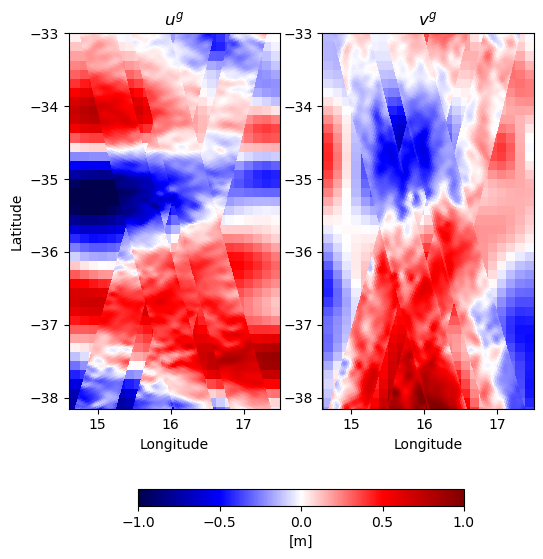

In [64]:
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
im = axes[0].pcolormesh(dsc.longitude, dsc.latitude,
              dsc.ugosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u1.longitude, u1.latitude,
              u1.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u6.longitude, u6.latitude,
              u6.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )

axes[1].pcolormesh(dsc.longitude, dsc.latitude,
              dsc.vgosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v1.longitude, v1.latitude,
              v1.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v6.longitude, v6.latitude,
              v6.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].set_ylim([-38.15,-33])
axes[0].set_xlim([14.6,17.5])
axes[1].set_ylim([-38.15,-33])
axes[1].set_xlim([14.6,17.5])

axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.7)
cbar.set_label(r"[m]")
axes[0].set_title(r"$u^g$")
axes[1].set_title(r"$v^g$")

plt.savefig(op.join(ddir,"../Figs/ug-CMEMS-AR.pdf"))

In [16]:
vbins = np.linspace(-3e0,3e0,80)
sbins = np.linspace(0,3e0,40)
hist_c = xhist((strain 
               ).sel(latitude=slice(-38,-33),
                     longitude=slice(14.6,17.5)
                     ).rename('strain'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               (vort 
               ).sel(latitude=slice(-38,-33),
                     longitude=slice(14.6,17.5)
                    ).rename('vort'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_c

<xarray.DataArray 'histogram_strain_vort' (strain_bin: 39, vort_bin: 79)> Size: 25kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(39, 79))
Coordinates:
  * strain_bin  (strain_bin) float64 312B 0.03846 0.1154 0.1923 ... 2.885 2.962
  * vort_bin    (vort_bin) float64 632B -2.962 -2.886 -2.81 ... 2.81 2.886 2.962

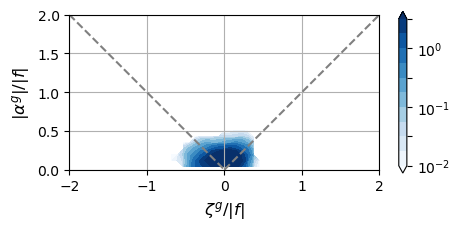

In [17]:
fig, ax = plt.subplots(figsize=(5,3))
# fig.set_tight_layout(True)

im = ax.contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

ax.plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
ax.plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

ax.set_xlim([-2,2])
ax.set_ylim([0,2])

ax.set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
ax.set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

ax.grid(True)
ax.set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=ax, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-ARjointPDF_CMEMS.pdf"))

# Kuroshio

In [54]:
ds04 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 4))
ds04.coords["num_lines"] = ("num_lines",range(len(ds04.num_lines)))
ds04.coords["num_pixels"] = ("num_pixels",range(len(ds04.num_pixels)))

ds19 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 19))
ds19.coords["num_lines"] = ("num_lines",range(len(ds19.num_lines)))
ds19.coords["num_pixels"] = ("num_pixels",range(len(ds19.num_pixels)))
ds04,ds19

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [55]:
maskn4 = xr.DataArray(ds04.latitude.where(ds04.latitude<38.4).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
masks4 = xr.DataArray(ds04.latitude.where(ds04.latitude>33).to_masked_array().mask,
                     dims=ds04.latitude.dims,
                     coords=ds04.latitude.coords
                    )
xo04 = ds04.where(~maskn4,drop=True).where(~masks4,drop=True)

maskn9 = xr.DataArray(ds19.latitude.where(ds19.latitude<38.4).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
masks9 = xr.DataArray(ds19.latitude.where(ds19.latitude>33).to_masked_array().mask,
                     dims=ds19.latitude.dims,
                     coords=ds19.latitude.coords
                    )
xo19 = ds19.where(~maskn9,drop=True).where(~masks9,drop=True)
xo04, xo19

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 38.65 38.65 ... 32.76
     longitude     (num_lines, num_pixels) float64 177kB 157.4 157.4 ... 157.5
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6775 6776 6777 6778 ... 7093 7094 7095
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 6

In [56]:
inp = 3

mask04 = xr.DataArray(xo04.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo04.ssha_detided.isel(cycle_num=0).coords
                    )
mm04 = xr.DataArray(mask04.where(mask04<.5
                              ).to_masked_array().mask,
                   dims=xo04.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo04.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask19 = xr.DataArray(xo19.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo19.ssha_detided.isel(cycle_num=0).coords
                    )
mm19 = xr.DataArray(mask19.where(mask19<.5
                              ).to_masked_array().mask,
                   dims=xo19.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo19.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm04, mm19

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        ...,
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 2766 2767 2768 2769 ... 3084 3085 3086
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 38.64 38.64 ... 32.77
     longitude   (num_lines, num_pixels) float64 162kB 157.4 157.4 ... 157.5,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False

In [57]:
dsv4 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass004/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass019/SSVs_SwotDiag.zarr"))
u4 = dsv4.ug.where(~maskn4,drop=True).where(~masks4,drop=True)
u9 = dsv9.ug.where(~maskn9,drop=True).where(~masks9,drop=True)
v4 = dsv4.vg.where(~maskn4,drop=True).where(~masks4,drop=True)
v9 = dsv9.vg.where(~maskn9,drop=True).where(~masks9,drop=True)

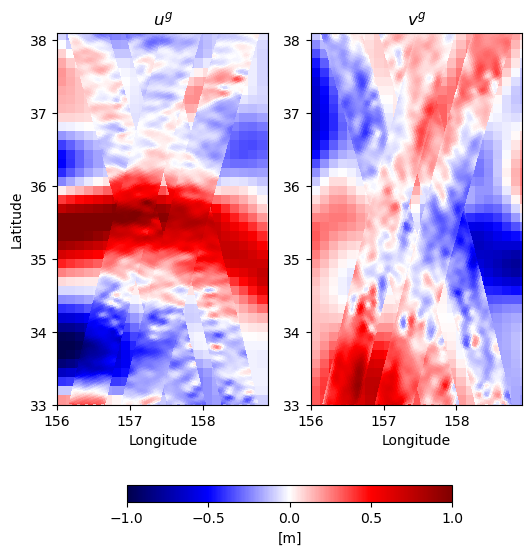

In [58]:
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
im = axes[0].pcolormesh(dsc.longitude, dsc.latitude,
              dsc.ugosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u4.longitude, u4.latitude,
              u4.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )

axes[1].pcolormesh(dsc.longitude, dsc.latitude,
              dsc.vgosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v4.longitude, v4.latitude,
              v4.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v9.longitude, v9.latitude,
              v9.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].set_ylim([33,38.1])
axes[0].set_xlim([156,158.9])
axes[1].set_ylim([33,38.1])
axes[1].set_xlim([156,158.9])

axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.7)
cbar.set_label(r"[m]")
axes[0].set_title(r"$u^g$")
axes[1].set_title(r"$v^g$")

plt.savefig(op.join(ddir,"../Figs/ug-CMEMS-Kx.pdf"))

In [100]:
vbins = np.linspace(-3e0,3e0,80)
sbins = np.linspace(0,3e0,40)
hist_c = xhist((strain 
               ).sel(latitude=slice(33,38.1),
                     longitude=slice(156,158.9)
                     ).rename('strain'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               (vort 
               ).sel(latitude=slice(33,38.1),
                     longitude=slice(156,158.9)
                    ).rename('vort'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_c

<xarray.DataArray 'histogram_strain_vort' (strain_bin: 39, vort_bin: 79)> Size: 25kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(39, 79))
Coordinates:
  * strain_bin  (strain_bin) float64 312B 0.03846 0.1154 0.1923 ... 2.885 2.962
  * vort_bin    (vort_bin) float64 632B -2.962 -2.886 -2.81 ... 2.81 2.886 2.962

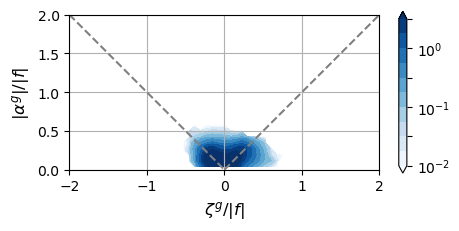

In [102]:
fig, ax = plt.subplots(figsize=(5,3))
# fig.set_tight_layout(True)

im = ax.contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

ax.plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
ax.plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

ax.set_xlim([-2,2])
ax.set_ylim([0,2])

ax.set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
ax.set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

ax.grid(True)
ax.set_aspect('equal')fig, ax = plt.subplots(figsize=(5,3))
# fig.set_tight_layout(True)

im = ax.contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

ax.plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
ax.plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

ax.set_xlim([-2,2])
ax.set_ylim([0,2])

ax.set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
ax.set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

ax.grid(True)
ax.set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=ax, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-KxjointPDF_CMEMS.pdf"))

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=ax, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-KxjointPDF_CMEMS.pdf"))

# Gulf Stream

In [49]:
ds09 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 9))
ds09.coords["num_lines"] = ("num_lines",range(len(ds09.num_lines)))
ds09.coords["num_pixels"] = ("num_pixels",range(len(ds09.num_pixels)))

ds22 = xr.open_zarr(op.join(ddir,"SWOT_no_IT/HYCOM/CalVal_pass%03d_v2.0.1.zarr"
                            % 22))
ds22.coords["num_lines"] = ("num_lines",range(len(ds22.num_lines)))
ds22.coords["num_pixels"] = ("num_pixels",range(len(ds22.num_pixels)))
ds09,ds22

(<xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
     longitude     (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9860, 69), meta=np.ndarray>
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 571MB dask.array<chunksize=(1, 9860, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 582MB
 Dimensions:       (cycle_num: 105, num_lines: 9860, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 79kB 0 1 2 3 4 ... 9855 9856 9857 9858 9859
   * num_pixels  

In [50]:
maskn9 = xr.DataArray(ds09.latitude.where(ds09.latitude<37.9).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
masks9 = xr.DataArray(ds09.latitude.where(ds09.latitude>32.5).to_masked_array().mask,
                     dims=ds09.latitude.dims,
                     coords=ds09.latitude.coords
                    )
xo09 = ds09.where(~maskn9,drop=True).where(~masks9,drop=True)

maskn2 = xr.DataArray(ds22.latitude.where(ds22.latitude<37.9).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
masks2 = xr.DataArray(ds22.latitude.where(ds22.latitude>32.5).to_masked_array().mask,
                     dims=ds22.latitude.dims,
                     coords=ds22.latitude.coords
                    )
xo22 = ds22.where(~maskn2,drop=True).where(~masks2,drop=True)
xo09, xo22

(<xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 66 67 68
     latitude      (num_lines, num_pixels) float64 177kB 32.5 32.5 ... 37.9 37.89
     longitude     (num_lines, num_pixels) float64 177kB 284.5 284.5 ... 287.4
 Data variables:
     ssha_detided  (cycle_num, num_lines, num_pixels) float64 19MB dask.array<chunksize=(1, 321, 69), meta=np.ndarray>,
 <xarray.Dataset> Size: 19MB
 Dimensions:       (cycle_num: 105, num_lines: 321, num_pixels: 69)
 Coordinates:
   * cycle_num     (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
   * num_lines     (num_lines) int64 3kB 2794 2795 2796 2797 ... 3112 3113 3114
   * num_pixels    (num_pixels) int64 552B 0 1 2 3 4 5 6 ... 62 63 64 65 6

In [51]:
inp = 3

mask09 = xr.DataArray(xo09.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo09.ssha_detided.isel(cycle_num=0).coords
                    )
mm09 = xr.DataArray(mask09.where(mask09<.5
                              ).to_masked_array().mask,
                   dims=xo09.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo09.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mask22 = xr.DataArray(xo22.ssha_detided.to_masked_array().mask.mean(axis=0), 
                     dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                     coords=xo22.ssha_detided.isel(cycle_num=0).coords
                    )
mm22 = xr.DataArray(mask22.where(mask22<.5
                              ).to_masked_array().mask,
                   dims=xo22.ssha_detided.isel(cycle_num=0).dims, 
                   coords=xo22.ssha_detided.isel(cycle_num=0).coords
                  ).isel(num_pixels=slice(inp,-inp))
mm09, mm22

(<xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        [ True, False, False, ...,  True,  True,  True],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ..., False, False,  True],
        [ True,  True,  True, ...,  True,  True,  True]], shape=(321, 63))
 Coordinates:
   * num_lines   (num_lines) int64 3kB 6747 6748 6749 6750 ... 7065 7066 7067
   * num_pixels  (num_pixels) int64 504B 3 4 5 6 7 8 9 ... 59 60 61 62 63 64 65
     cycle_num   int64 8B 474
     latitude    (num_lines, num_pixels) float64 162kB 32.49 32.49 ... 37.91
     longitude   (num_lines, num_pixels) float64 162kB 284.6 284.6 ... 287.4,
 <xarray.DataArray (num_lines: 321, num_pixels: 63)> Size: 20kB
 array([[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ..., False,  True,  True],
        [ True,  True,  True

In [52]:
dsv2 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass022/SSVs_SwotDiag.zarr"))
dsv9 = xr.open_zarr(op.join(ddir,"CalVal/geos/global/Pass009/SSVs_SwotDiag.zarr"))
u2 = dsv2.ug.where(~maskn2,drop=True).where(~masks2,drop=True)
u9 = dsv9.ug.where(~maskn9,drop=True).where(~masks9,drop=True)
v2 = dsv2.vg.where(~maskn2,drop=True).where(~masks2,drop=True)
v9 = dsv9.vg.where(~maskn9,drop=True).where(~masks9,drop=True)

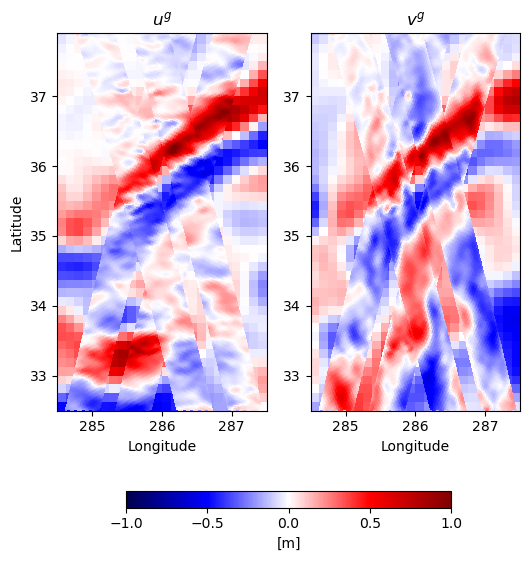

In [53]:
fig, axes = plt.subplots(figsize=(6,7), nrows=1, ncols=2)
im = axes[0].pcolormesh(dsc.longitude+360, dsc.latitude,
              dsc.ugosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u9.longitude, u9.latitude,
              u9.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].pcolormesh(u2.longitude, u2.latitude,
              u2.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )

axes[1].pcolormesh(dsc.longitude+360, dsc.latitude,
              dsc.vgosa.isel(time=8),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v9.longitude, v9.latitude,
              v9.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[1].pcolormesh(v2.longitude, v2.latitude,
              v2.isel(cycle_num=11),
              vmax=1., vmin=-1., cmap="seismic",
              rasterized=True
             )
axes[0].set_ylim([32.5,37.9])
axes[0].set_xlim([284.5,287.5])
axes[1].set_ylim([32.5,37.9])
axes[1].set_xlim([284.5,287.5])

axes[0].set_aspect("equal")
axes[1].set_aspect("equal")
axes[0].set_xlabel(r"Longitude")
axes[0].set_ylabel(r"Latitude")
axes[1].set_xlabel(r"Longitude")

cbar = fig.colorbar(im, ax=axes, orientation="horizontal", shrink=.7)
cbar.set_label(r"[m]")
axes[0].set_title(r"$u^g$")
axes[1].set_title(r"$v^g$")

plt.savefig(op.join(ddir,"../Figs/ug-CMEMS-GS.pdf"))

In [18]:
vbins = np.linspace(-3e0,3e0,80)
sbins = np.linspace(0,3e0,40)
hist_c = xhist((strain 
               ).sel(latitude=slice(32.5,37.9),
                     longitude=slice(284.5-360,287.5-360)
                     ).rename('strain'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               (vort 
               ).sel(latitude=slice(32.5,37.9),
                     longitude=slice(284.5-360,287.5-360)
                    ).rename('vort'
                             ).chunk({'latitude':-1,'longitude':-1}), 
               bins=[sbins, vbins], density=True
              ).compute()
hist_c

<xarray.DataArray 'histogram_strain_vort' (strain_bin: 39, vort_bin: 79)> Size: 25kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(39, 79))
Coordinates:
  * strain_bin  (strain_bin) float64 312B 0.03846 0.1154 0.1923 ... 2.885 2.962
  * vort_bin    (vort_bin) float64 632B -2.962 -2.886 -2.81 ... 2.81 2.886 2.962

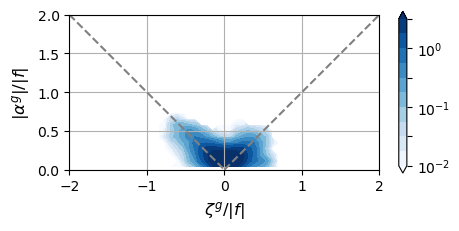

In [19]:
fig, ax = plt.subplots(figsize=(5,3))
# fig.set_tight_layout(True)

im = ax.contourf(hist_c.vort_bin,
                 hist_c.strain_bin,
                 hist_c, 
                 cmap='Blues', locator=ticker.LogLocator(), 
                 norm=clr.LogNorm(), levels=np.logspace(-2,.5,11),
                 extend='both'
#                       rasterized=True
               )

ax.plot(np.linspace(0,3,5),np.linspace(0,3,5),c='grey',ls='--')
ax.plot(np.linspace(-3,0,5),np.linspace(3,0,5),c='grey',ls='--')

ax.set_xlim([-2,2])
ax.set_ylim([0,2])

ax.set_xlabel(r"$\zeta^g/|f|$", fontsize=12)
ax.set_ylabel(r"$|\alpha^g|/|f|$", fontsize=12)

ax.grid(True)
ax.set_aspect('equal')

# fig.subplots_adjust(hspace=.06, wspace=.12)
# cbar = fig.colorbar(im, orientation='horizontal', ax=axes, shrink=.4, 
#                     ticks=[1e-4,1e-3,1e-2,1e-1,1e0])
cbar = fig.colorbar(im, ax=ax, shrink=.7)
# cbar.set_ticks([1e-2,1e-1,0,1])

plt.savefig(op.join(ddir,"../Figs/vort-strain-GSjointPDF_CMEMS.pdf"))

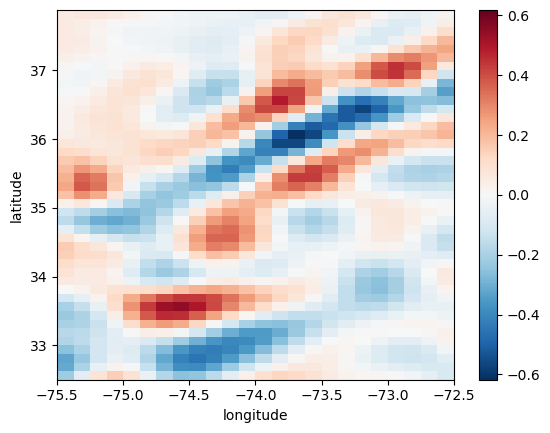

In [20]:
(vort).isel(time=8).sel(latitude=slice(32.5,37.9),
                     longitude=slice(284.5-360,287.5-360)
                    ).plot(rasterized=True)